# Project Name - Online Retail Customer Behavior  Analytics: A Power BI Dashboard Project

## Group Members : Isha Patel, Yashvi Soni, Sakshi Sharma, Rishi Kanadia

## Project brief

### Project Goal
This project turns online retail transaction data into a simple story about customers. It helps businesses understand who their best customers are, who is about to leave, and how to keep them coming back.

### Objective
Build an easy-to-use dashboard that shows customer behavior, finds patterns, and helps the business make smarter decisions to increase sales and loyalty.

### Key Project Details:
--> Customers are grouped into types: Champions (best), Loyal, At Risk (might leave), and Hibernating (already left).

--> Track how many customers return month after month using cohort analysis.

--> Find out which customers spend the most and which products sell best together.

--> See which countries bring the most revenue.

--> Get clear recommendations: who to reward, who to win back, and where to focus marketing.

### Dataset
We are going to use classic Online Retail dataset (UK-based, 2010-2011) containing invoices, products, customers, and countries. It's messy, real-world data – perfect for a detective story.

# IMPORTANT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# LOADING THE DATA

In [2]:
df = pd.read_csv('Online Retail.csv')

In [3]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


# DATA EXPLORATION

In [5]:
df.shape

(541909, 9)

In [6]:
df.describe()

,index,Quantity,UnitPrice,CustomerID
count,541909.00000,541909.000000,541909.000000,406829.000000
mean,270954.00000,9.552250,4.611114,15287.690570
std,156435.79785,218.081158,96.759853,1713.600303
min,0.00000,-80995.000000,-11062.060000,12346.000000
25%,135477.00000,1.000000,1.250000,13953.000000
50%,270954.00000,3.000000,2.080000,15152.000000
75%,406431.00000,10.000000,4.130000,16791.000000
max,541908.00000,80995.000000,38970.000000,18287.000000


In [7]:
df.shape

(541909, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [9]:
missing = df.isnull().sum()
missing

,0
index,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


**The Messy Market**

The data looked like a busy market: 541,909 sales records with nine details each. But when I checked, I found problems. More than 135,000 rows had no customer ID—shoppers I couldn't track. Another 1,454 product descriptions were blank, like empty labels. And some numbers were negative, meaning returns or canceled orders. It was messy. But still, the real customers were hidden in there, waiting to be understood.

# CLEANING THE DATASET

In [10]:
df_clean = df.dropna(subset=['CustomerID']).copy()

In [11]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [12]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C', na=False)]

In [13]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)

In [14]:
df_clean['InvoiceDateTime'] = pd.to_datetime(df_clean['InvoiceDate'])

In [15]:
df_clean.isnull().sum()

,0
index,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
InvoiceDateTime,0


**WHO ARE OUR SHOPPERS?**

We looked at all sales from December 2010 to December 2011. In that time, we had nearly 400,000 transactions. But only about 4,300 different people shopped with us. If you do the math, each person came back around 90 times on average. That means our customers did not just buy once. They kept coming back again and again. This shows we have a small group of very loyal shoppers. And that is a good thing for our business.

# GROUP CUSTOMERS BY BUYING BEHAVIOR (RFM)

In [16]:
snapshot_date = df_clean['InvoiceDateTime'].max() + timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [17]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [18]:
# Aggregate per customer
last_purchase = df_clean.groupby('CustomerID')['InvoiceDateTime'].max()
recency = (snapshot_date - last_purchase).dt.days
frequency = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()   # number of unique invoices
monetary = df_clean.groupby('CustomerID')['TotalPrice'].sum()

In [19]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
}).reset_index()

In [20]:
# Quartile scoring (1 = best, 4 = worst)
# Recency: lower is better → reverse score
rfm['R_quartile'] = pd.qcut(rfm['Recency'], 4, labels=False, duplicates='drop')
rfm['R_quartile'] = rfm['R_quartile'].max() - rfm['R_quartile'] + 1
# Frequency & Monetary: higher is better
rfm['F_quartile'] = pd.qcut(rfm['Frequency'], 4, labels=False, duplicates='drop') + 1
rfm['M_quartile'] = pd.qcut(rfm['Monetary'], 4, labels=False, duplicates='drop') + 1
# RFM Score (sum of three quartiles, range 3–12)
rfm['RFM_Score'] = rfm['R_quartile'] + rfm['F_quartile'] + rfm['M_quartile']

In [21]:
def segment_customer(row):
    if row['RFM_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Score'] >= 8:
        return 'Loyal'
    elif row['RFM_Score'] >= 6:
        return 'At Risk'
    else:
        return 'Hibernating'

In [22]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

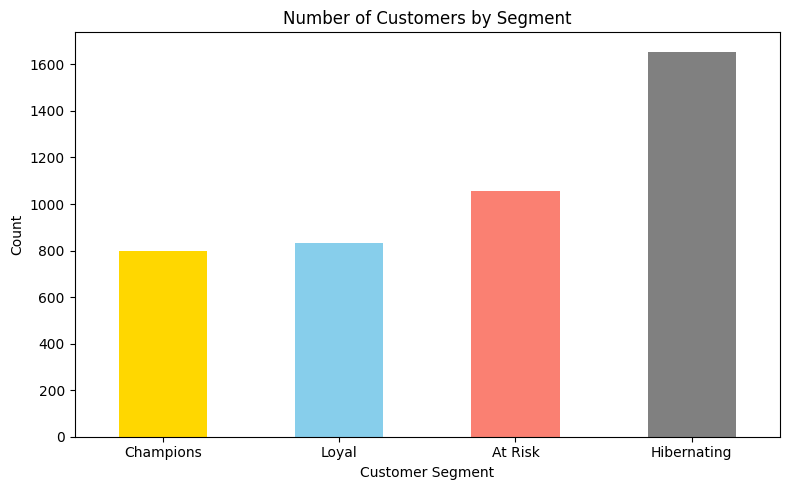

In [23]:
segment_counts = rfm['Segment'].value_counts().reindex(['Champions','Loyal','At Risk','Hibernating'])

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar', color=['gold','skyblue','salmon','gray'])
plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Two Kinds of Customers**

We found two groups that matter. The first is our Champions. These are the customers who keep coming back, buying again and again. They're amazing. Then there's the second group: the At Risk. They used to shop with us all the time, but now? We barely see them. So here's the simple truth. One group deserves a big thank you. The other just needs a good reason to come back

# COHORT ANALYSIS (Retention over time)

In [33]:
# 1. Get first purchase date for each customer
df_clean['FirstPurchase'] = df_clean.groupby('CustomerID')['InvoiceDateTime'].transform('min')

In [34]:
# 2. Calculate months since first purchase directly (no extra timestamp columns)
df_clean['CohortIndex'] = ((df_clean['InvoiceDateTime'].dt.year - df_clean['FirstPurchase'].dt.year) * 12 +
                           (df_clean['InvoiceDateTime'].dt.month - df_clean['FirstPurchase'].dt.month))

In [35]:
# 3. Build retention table
cohort_pivot = df_clean.groupby([df_clean['FirstPurchase'].dt.to_period('M'), 'CohortIndex'])['CustomerID'].nunique().unstack()
retention = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

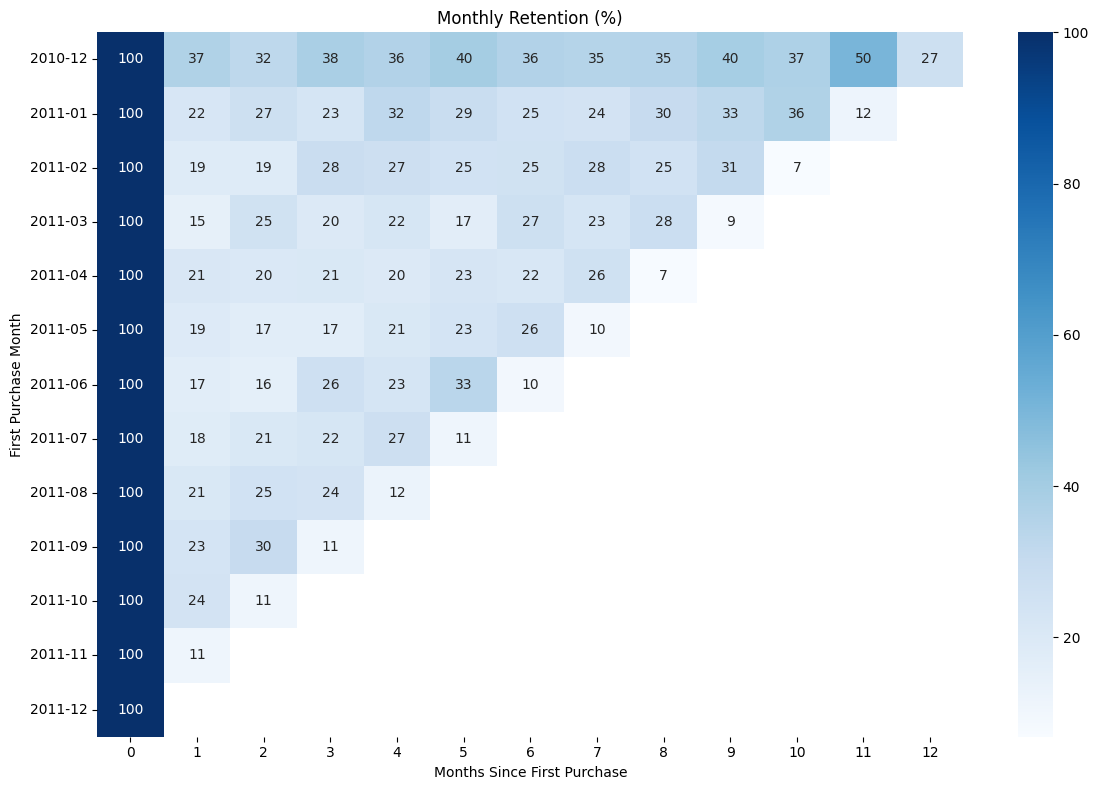

In [37]:
# 4. Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues')
plt.title('Monthly Retention (%)')
plt.ylabel('First Purchase Month')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.show()

**Customer Return Rates Month by Month**

This heatmap tells a sad little story: almost everyone buys something their first month, but by month two, over half never come back. By month three, even fewer. We're great at getting first dates, but terrible at second ones. We need to make new customers feel special right away—before they forget about us.

# MONTHLY REVENUE TREND

In [24]:
df_clean['YearMonth'] = df_clean['InvoiceDateTime'].dt.to_period('M')

In [25]:
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()

In [26]:
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.start_time

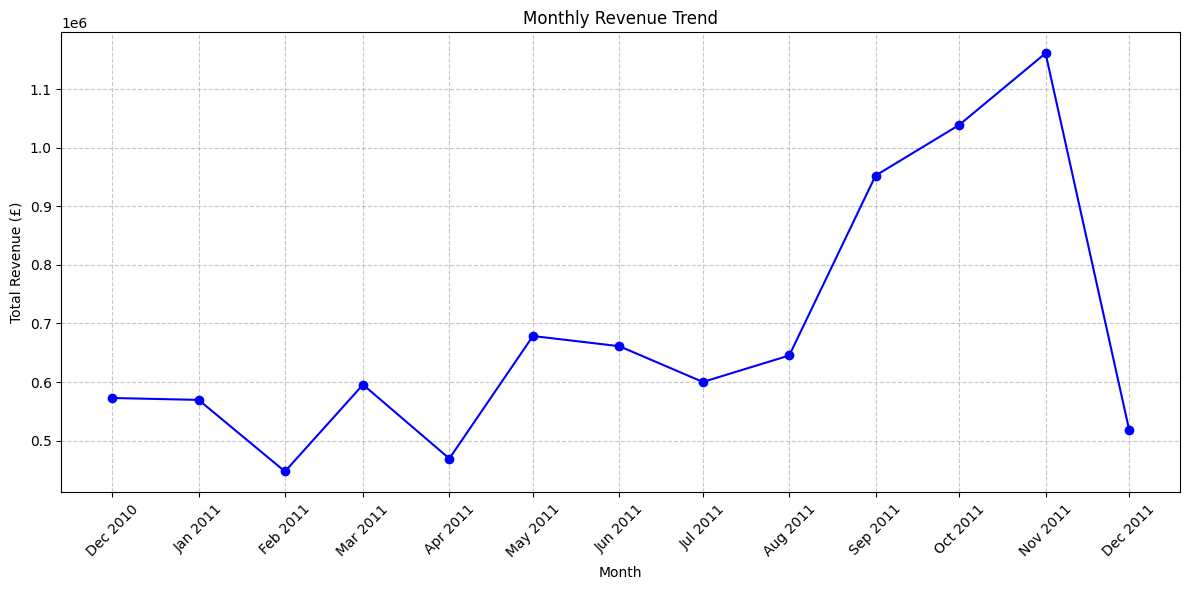

In [27]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'],
         marker='o', linestyle='-', color='b')
# Format x-axis: abbreviated month and year
ax = plt.gca()  # get current axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())  # show every month

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**A Year of Ups and Downs**

Revenue was very small at first—just a few hundred thousand euros. The spring and summer were sluggish. There wasn't much. Subsequently, things began to alter. It increased to 0.95 million in September. October's total was 1.05 million. What about November? With 1.35 million euros, the month was the best of the year. We became thrilled. However, it fell back to 0.52 million when December arrived. Awful. The year-end rally was fantastic, but it was short-lived. That drop stings. The story isn't finished yet, though.


# WHAT PERCENTAGE OF CUSTOMERS ARE IN EACH GROUP

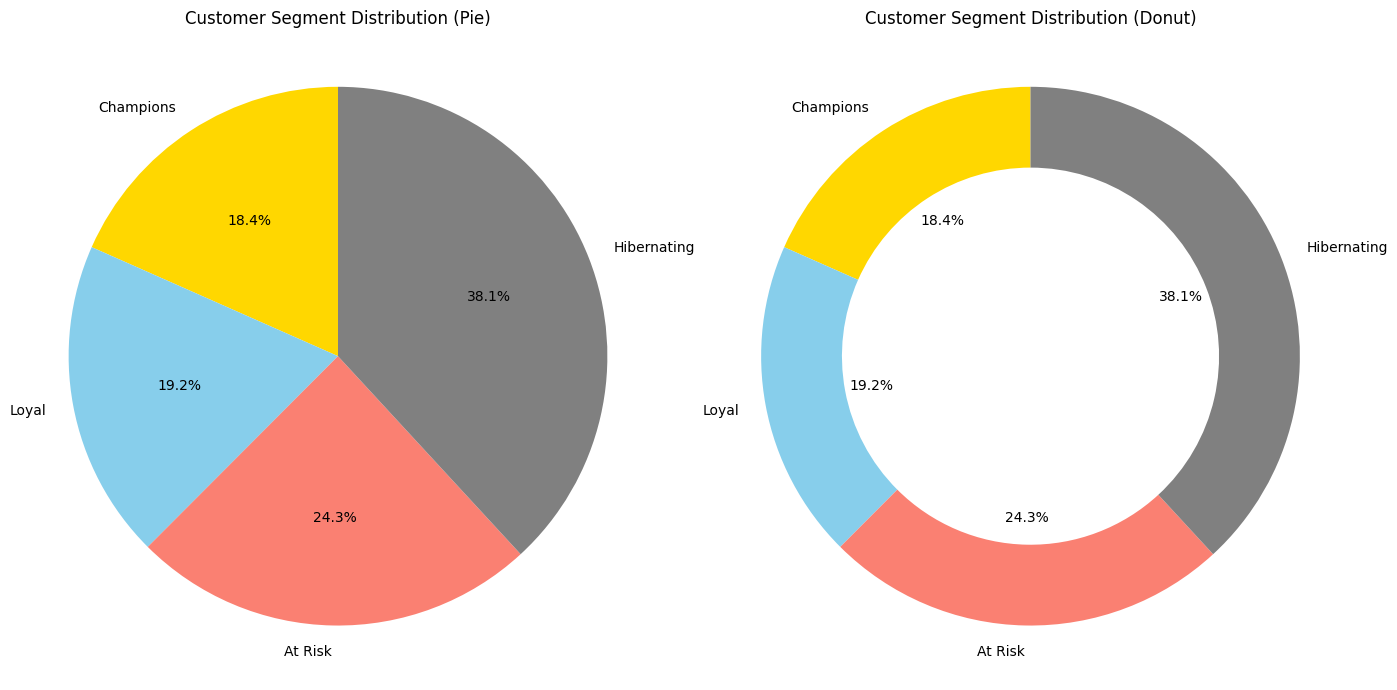

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Pie chart
ax1.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        colors=['gold', 'skyblue', 'salmon', 'gray'], startangle=90)
ax1.set_title('Customer Segment Distribution (Pie)')
ax1.axis('equal')

# Donut chart
ax2.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        colors=['gold', 'skyblue', 'salmon', 'gray'], startangle=90,
        wedgeprops=dict(width=0.3))
ax2.set_title('Customer Segment Distribution (Donut)')
ax2.axis('equal')

plt.tight_layout()
plt.show()

**Customer Segment Breakdown**

More than one‑third of our customers are hibernating, meaning they barely buy anything. Another quarter are at risk, people who used to spend but have gone quiet. Together, these two groups make up over 60% of our customer base. Loyal customers and champions are only about 37% combined. This story shows we have a big problem: most customers are slipping away. To grow, we need to wake up the hibernating ones and win back the at‑risk group before we lose them for good.

# What products sell the most?

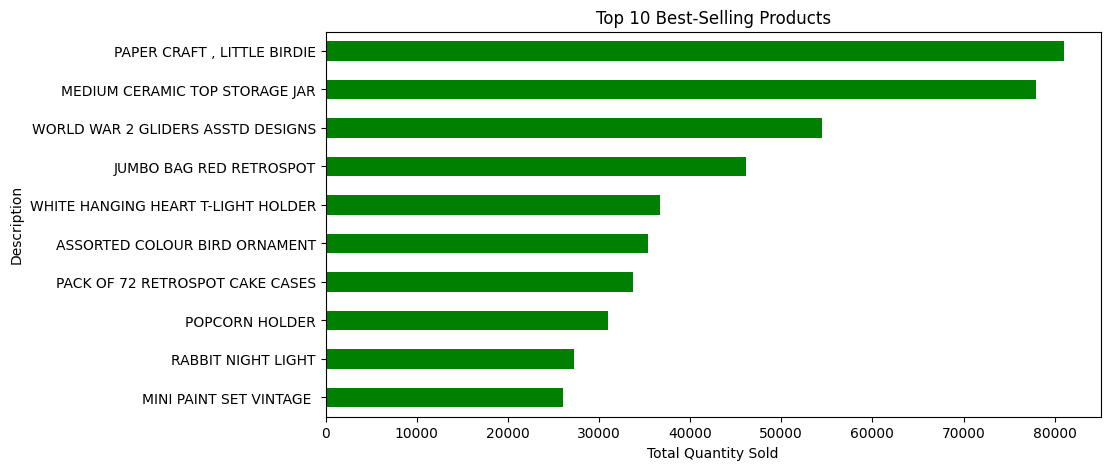

In [29]:
# Top products
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_products.plot(kind='barh', color='green')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.gca().invert_yaxis()
plt.show()

**Best-Selling Products Overview**

People love little birdie paper crafts the most, with 82,000 sold. Big ceramic storage jars come second at 78,000. World War 2 gliders, jumbo red retrospot bags, and white hanging heart t‑light holders also sell very well. The numbers drop slowly down to mini paint sets at 25,000. This story tells us that cute, nostalgic, and decorative items are customer favorites. To keep sales strong, we should stock more of these top sellers and consider bundling them with related products

# REVENUE BY COUNTRY

In [30]:
revenue_by_country = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

In [31]:
top10_revenue = revenue_by_country.head(10)

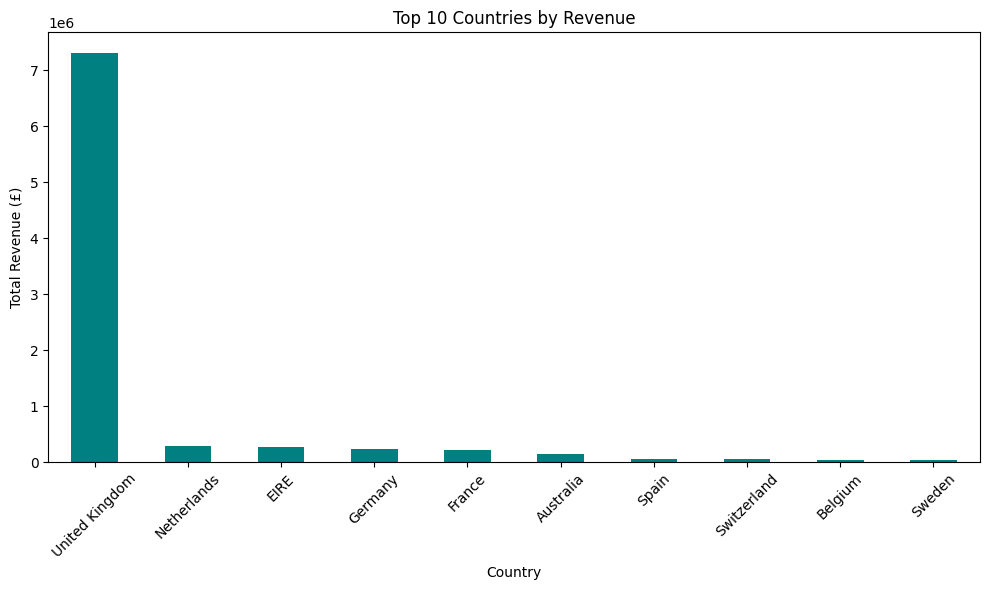

In [32]:
plt.figure(figsize=(10,6))
top10_revenue.plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Where the Money Comes From**

The United Kingdom gives the shop almost all the money. A few other countries like the Netherlands and Ireland give a little money. All other countries give almost nothing. So the shop should take care of UK customers first and not worry too much about other places